In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt



In [19]:
# loading dataset
df = pd.read_csv('400lvl_Classroom_Temperature_Log.csv')


In [20]:
#checking data
print(df.head())
print(df.info())
print(df.describe())

        Day      Date     Time        Reading  Temp FL (°C)  Temp FR (°C)  \
0    Friday  6/3/2026  7:30 AM   Before class          26.8          24.7   
1       NaN       NaN  9:00 AM   Class starts          27.3          28.9   
2       NaN       NaN  2:00 PM   End of class          30.9          30.8   
3       NaN       NaN  7:30 PM  Evening check          26.9          26.6   
4  Saturday  7/3/2026  7:30 AM   Before class          27.3          28.0   

   Temp BL (°C)  Temp BR (°C) AC On? Windows Open?  ... Outdoor Temp (°C)  \
0          25.8          25.0     NO           YES  ...                26   
1          27.6          27.4     NO           YES  ...                30   
2          29.9          30.3     NO           YES  ...                40   
3          26.6          26.7    YES            NO  ...                31   
4          27.6          26.0     NO           YES  ...                25   

   Door Height Measurement (cm)  Door Width Measurement (cm)  FL Grid (cm²

In [21]:
#preprocessing starts here

#encoding categorical columns
categorical_cols = ['AC On?', 'Windows Open?', 'Class In Session?']
for col in categorical_cols:
    df[col] = df[col].map({'YES': 1, 'NO': 0})

In [22]:
#converting time to numeric values
#by turning 7:30 AM to 7.5 and 2:00 PM to 14.0 etc
def convert_time_to_float(time_str):
    t = time_str.split()[0]
    ampm = time_str.split()[1]
    h, m = map(int, t.split(':'))
    if ampm.upper() == 'PM' and h != 12:
        h += 12
    if ampm.upper() == 'AM' and h == 12:
        h = 0
    return h + m/60

df['Time_numeric'] = df['Time'].apply(convert_time_to_float)

In [23]:
print(df[['Time', 'Time_numeric']].head(10))

      Time  Time_numeric
0  7:30 AM           7.5
1  9:00 AM           9.0
2  2:00 PM          14.0
3  7:30 PM          19.5
4  7:30 AM           7.5
5  9:00 AM           9.0
6  2:00 PM          14.0
7  7:30 PM          19.5
8  7:30 AM           7.5
9  9:00 AM           9.0


In [24]:
#target variable
df['Temp_Avg'] = df[['Temp FL (°C)', 'Temp FR (°C)', 'Temp BL (°C)', 'Temp BR (°C)']].mean(axis=1) #computes the average of the four temperature sensors in the classroom

In [26]:
drop_cols = [
    'Day', 'Date', 'Time', 'Reading',
    'Temp FL (°C)', 'Temp FR (°C)', 'Temp BL (°C)', 'Temp BR (°C)',
    'Side Window Size (cm²)\n[FIXED]',
    'Back Window Size (cm²)\n[FIXED]',
    'FL Grid (cm²)', 'FR Grid (cm²)', 'BL Grid (cm²)', 'BR Grid (cm²)',
    'Area of Class (cm²)', 'Front Height of Class (cm)', 'Back Height of Class (cm)',
    'Door Height Measurement (cm)', 'Door Width Measurement (cm)'
]
X = df.drop(columns=drop_cols)#features/input variables used for prediction
y = df['Temp_Avg']#target/output variable (average temp)

#preprocessing ended here

In [27]:
#splitting of our data to train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(22, 8)
(22,)
(6, 8)
(6,)


In [28]:
#choosing a model and training it
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
#predict and evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error: {mae:.2f} °C") #average error in °C. Lower is better
print(f"Root Mean Squared Error: {rmse:.2f} °C") #penalizes bigger errors more than MAE. Lower is better

Mean Absolute Error: 0.31 °C
Root Mean Squared Error: 0.37 °C


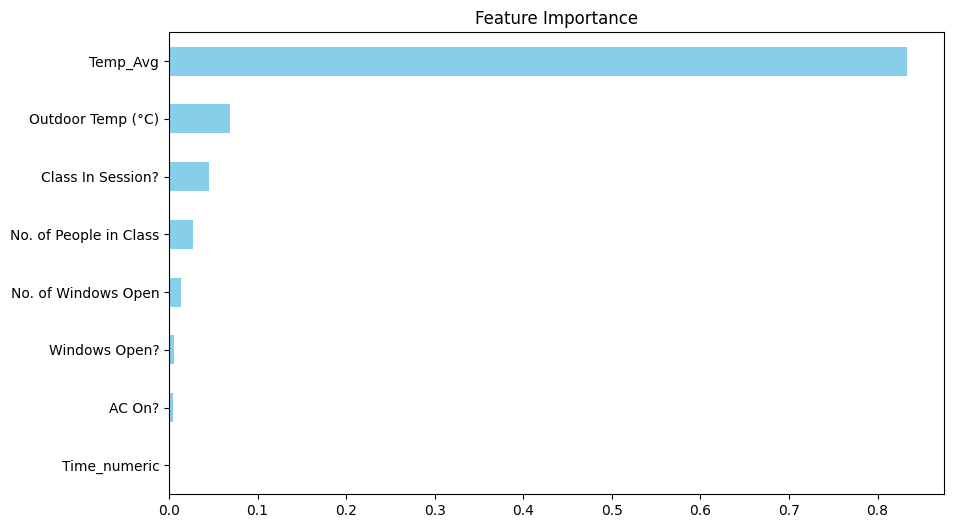

In [35]:
#feature importance showing which features contributed most to the average temperature predictions 

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', figsize=(10,6), color='skyblue')
plt.title("Feature Importance")
plt.show()

In [42]:
#checking for any outliers
import numpy as np
import pandas as pd
from scipy import stats

# Assume df['Temp_Avg'] already exists
temps = df['Temp_Avg']

# Compute Z-scores
z_scores = np.abs(stats.zscore(temps))

# Identify outliers (commonly z > 3)
df['Outlier'] = z_scores > 3  # True = outlier, False = normal

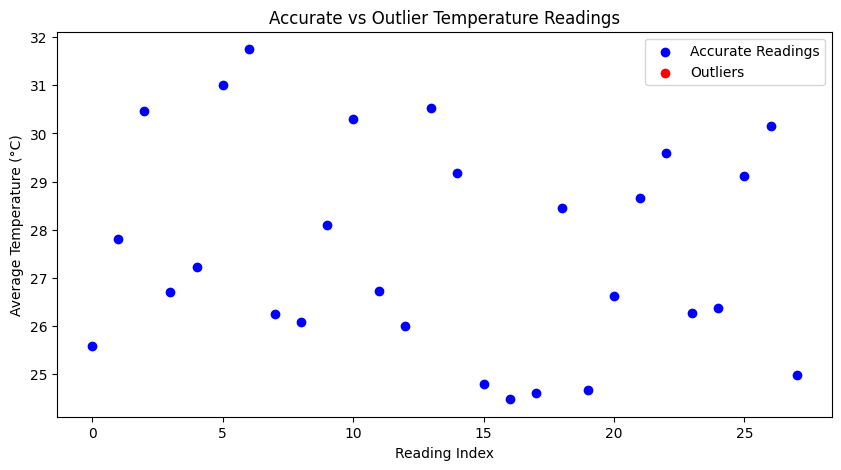

In [41]:
plt.figure(figsize=(10,5))

# Plot normal readings
plt.scatter(df.index[~df['Outlier']], temps[~df['Outlier']], color='blue', label='Accurate Readings')

# Plot outliers
plt.scatter(df.index[df['Outlier']], temps[df['Outlier']], color='red', label='Outliers')

plt.xlabel("Reading Index")
plt.ylabel("Average Temperature (°C)")
plt.title("Accurate vs Outlier Temperature Readings")
plt.legend()
plt.show()

In [ ]:
#in conclusion

#our data set is quite small but, working with what we have, Mean Absolute Error (MAE) = 0.31 °C

#RMSE also measures prediction error, but heavily penalizes large mistakes.
#A value of 0.37 °C means even our worst predictions aren’t far off.
#The fact that RMSE is only slightly higher than MAE means your errors are consistently small — no huge outliers.
#Our model is very reliable at predicting average classroom temperature.
#The features included (temp Average,outdoor temp,class in session, number of people in class) are strong predictors.